# Reinforce with baseline

The objective of plain REINFORCE is this:

$\nabla_\theta J(\theta) \approx \mathbb{E} [\nabla_\theta \log \pi_\theta(a_t|s_t) G_t]$ 

Where $G_t$ is a normalized return. It works but depending on the shape of the action/state space that can be quite noisy having a high variance and such. A solution was to subtract a base line, meaning what is this worst or better then what I expected.

Therefore in the baseline we use an Advantage function which computes $G_t -b(s_t)$ a good estimation for this would be the Value function which would normalize the actions accordantly to a prediction of the value of this state following this policy. Since we mostly cannot compute directly the value function we instead use a Value Network to approximate the Value function $V(s)$.

Therefore the Loss of the policy network is defined as:

$L_\pi = -\mathbb{E}[\log \pi(a_t|s_t) A_t]$

and the loss for the value is:

$L_v = \mathbb{E}[(V(s_t) - G_t)^2]$

In [1]:
from typing import Optional, Sequence, Tuple

import gymnasium as gym
import numpy as np
import torch
from torch import Tensor
from torch.distributions import Categorical

from pg_env import (
    EarlyStoppingConfig,
    EnvFn,
    EpisodeBatch,
    MLPPolicy,
    MLPValue,
    make_cartpole_env,
    plot_training_history,
    run_demo_episode,
    set_seed,
    to_tensor,
    train_on_policy_agent,
)


In [2]:
def compute_discounted_returns(rewards: Sequence[float], gamma: float) -> Tensor:
    """
    Compute rewards-to-go:
        G_t = r_t + gamma * r_{t+1} + gamma^2 * r_{t+2} + ...

    Returns a 1D float32 tensor of shape [T].
    """
    returns = []
    running_return = 0.0

    for reward in reversed(rewards):
        running_return = reward + gamma * running_return
        returns.append(running_return)

    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32)

In [3]:
def mse(predicted, truth):
    return torch.mean((predicted - truth) ** 2)

In [4]:
class ReinforceBaselineAgent:
    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        hidden_sizes=(64, 64),
        learning_rate: float = 1e-3,
        gamma: float = 0.99,
        value_coef: float = 0.5,
        device: torch.device | None = None,
    ) -> None:
        self.device = device or torch.device("cpu")
        self.gamma = gamma
        self.value_coef = value_coef

        self.policy = MLPPolicy(
            obs_dim=obs_dim,
            act_dim=act_dim,
            hidden_sizes=hidden_sizes,
        ).to(self.device)

        self.value_net = MLPValue(
            obs_dim=obs_dim,
            hidden_sizes=hidden_sizes,
        ).to(self.device)

        self.optimizer = torch.optim.Adam(
            list(self.policy.parameters()) + list(self.value_net.parameters()),
            lr=learning_rate,
        )

        self.last_policy_loss: float = 0.0
        self.last_value_loss: float = 0.0
        self.last_entropy: float = 0.0

    def distribution(self, obs: np.ndarray) -> Categorical:
        obs_tensor = to_tensor(obs, self.device)
        logits = self.policy(obs_tensor)
        return Categorical(logits=logits)

    def sample_action(self, obs: np.ndarray) -> tuple[int, Tensor]:
        dist = self.distribution(obs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return int(action.item()), log_prob

    def predict_action(self, obs: np.ndarray) -> int:
        with torch.no_grad():
            obs_tensor = to_tensor(obs, self.device)
            logits = self.policy(obs_tensor)
            return int(torch.argmax(logits, dim=-1).item())

    def update_from_episode(self, episode: EpisodeBatch) -> float:
        obs_tensor = torch.as_tensor(
            np.asarray(episode.observations),
            dtype=torch.float32,
            device=self.device,
        )

        returns = compute_discounted_returns(episode.rewards, self.gamma).to(self.device)
        values = self.value_net(obs_tensor)

        advantages = returns - values

        log_probs = torch.cat(episode.log_probs).to(self.device)

        policy_loss = -(log_probs * advantages.detach()).mean()
        value_loss = mse(values,returns)

        with torch.no_grad():
            logits = self.policy(obs_tensor)
            dist = Categorical(logits=logits)
            entropy = dist.entropy().mean()

        loss = policy_loss + self.value_coef * value_loss

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.last_policy_loss = float(policy_loss.item())
        self.last_value_loss = float(value_loss.item())
        self.last_entropy = float(entropy.item())

        return float(policy_loss.item())

In [5]:
def build_reinforce_agent_from_env(
    env_fn: EnvFn,
    hidden_sizes: Sequence[int] = (64, 64),
    learning_rate: float = 1e-2,
    gamma: float = 0.99,
    device: Optional[torch.device] = None,
) -> ReinforceBaselineAgent:
    """
    Inspect one environment instance to infer observation and action sizes,
    then construct a compatible REINFORCE agent.
    """
    env = env_fn()

    assert isinstance(env.observation_space, gym.spaces.Box), "Expected Box observation space."
    assert isinstance(env.action_space, gym.spaces.Discrete), "Expected Discrete action space."

    obs_dim = int(np.prod(env.observation_space.shape))
    act_dim = int(env.action_space.n)

    env.close()

    return ReinforceBaselineAgent(
        obs_dim=obs_dim,
        act_dim=act_dim,
        hidden_sizes=hidden_sizes,
        learning_rate=learning_rate,
        gamma=gamma,
        device=device,
    )

[episode    1] train_return=  20.00 | loss=   6.5269 | eval_mean_return=   9.40
[episode   25] train_return=  15.00 | loss=   4.9964 | eval_mean_return=   9.20
[episode   50] train_return=  18.00 | loss=   5.8869 | eval_mean_return=   9.00
[episode   75] train_return=  11.00 | loss=   3.4532 | eval_mean_return=   9.80
[episode  100] train_return=  11.00 | loss=   4.0007 | eval_mean_return=  10.20
[episode  125] train_return=  25.00 | loss=   7.6793 | eval_mean_return=  10.30
[episode  150] train_return=  13.00 | loss=   3.7124 | eval_mean_return=  12.00
[episode  175] train_return=  30.00 | loss=   9.1158 | eval_mean_return=  13.80
[episode  200] train_return=  16.00 | loss=   4.2240 | eval_mean_return=  15.10
[episode  225] train_return=  26.00 | loss=   7.6244 | eval_mean_return=  82.20
[episode  250] train_return=  17.00 | loss=   4.7167 | eval_mean_return=  71.70
[episode  275] train_return=  16.00 | loss=   3.6000 | eval_mean_return= 101.10
[episode  300] train_return=  24.00 | lo

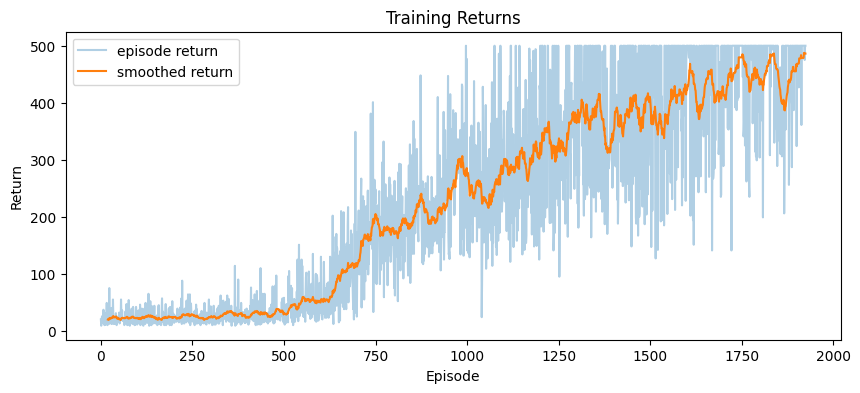

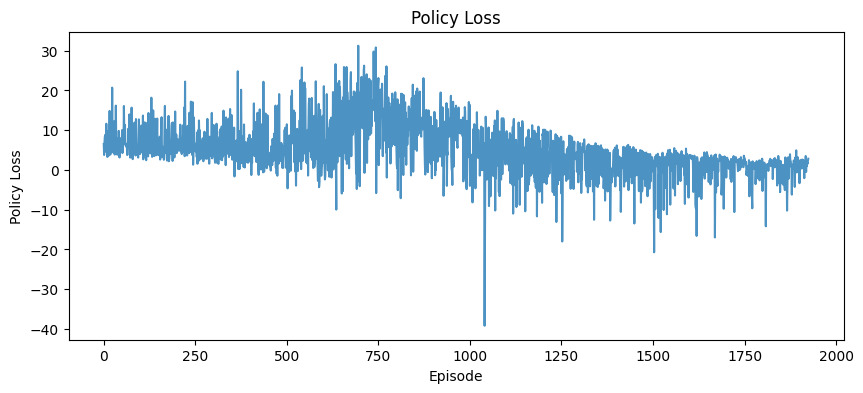

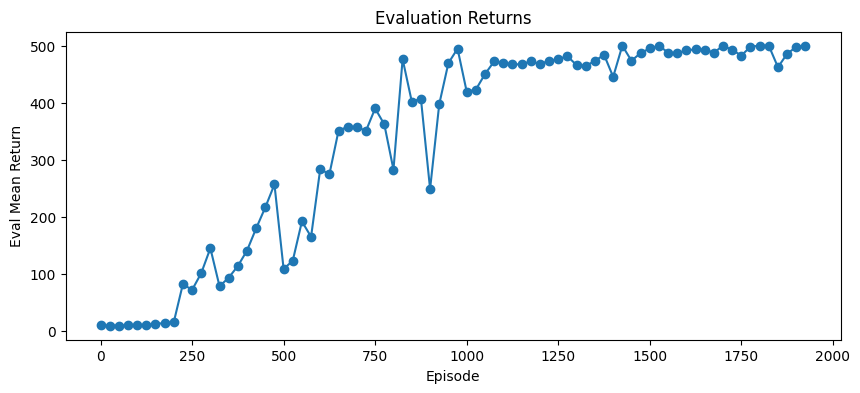

Stopped at iteration 1925: no eval improvement greater than 2.00 for 20 evals


In [8]:
set_seed(42)

env_fn: EnvFn = lambda: make_cartpole_env(render_mode=None)

agent = build_reinforce_agent_from_env(
    env_fn=env_fn,
    hidden_sizes=(32, 32),
    learning_rate=3e-4,
    gamma=0.99,
)

history = train_on_policy_agent(
    env_fn=env_fn,
    agent=agent,
    num_episodes=10_000,
    eval_every=25,
    eval_episodes=10,
    early_stopping=EarlyStoppingConfig(
        patience_evals=20,
        min_delta=2.0,
    ),
    verbose=True,
)

plot_training_history(history)

if history.stopped_early:
    print(f"Stopped at iteration {history.stop_iteration}: {history.stop_reason}")


In [9]:
visual_env: EnvFn = lambda: make_cartpole_env(render_mode="human")

run_demo_episode(visual_env, agent, greedy=True)


Demo return: 500.00


500.0